# Comparación de Welch y `spectrogram` para reconstruir la DSA

## Objetivo

Comparar la reconstrucción espectral obtenida mediante:

1. `scipy.signal.welch`, aplicado a épocas móviles de 2 segundos.
2. `scipy.signal.spectrogram`, aplicado a la señal completa.

La comparación se realiza frente a la matriz espectral original `.f_a` utilizando
Pearson, MAE y RMSE. También se comprueba directamente si las PSD generadas por
ambos procedimientos son numéricamente equivalentes.

Este notebook es exclusivamente experimental: **no modifica el código de la
aplicación**.

## Condiciones mantenidas constantes

- Mismo canal: C1 en unilateral; C1 izquierdo y C3 derecho en bilateral.
- Mismo filtro pasa-altos causal determinado por `LoFilter`.
- Ventana Hann de 2 s.
- Avance temporal de 1 s, equivalente a 1 s de solapamiento.
- Eliminación de la media mediante `detrend="constant"`.
- PSD con `scaling="density"` en µV²/Hz.
- Integración de cada bin multiplicando por 0,5 Hz.
- Conversión a dB respecto a 0,0001 µV RMS.
- Suavizado causal `rolling` con la duración indicada por `SpSmooth`.
- Los segundos no válidos se excluyen del suavizado.
- Barrido de desplazamientos entre 0 y 30 s.
- Misma timeline `.spa` y mismas máscaras para ambos estimadores.

### Interpretación previa

En la implementación Welch utilizada en el proyecto, cada llamada recibe
exactamente una época de 2 s y `nperseg` también vale 2 s. Por ello, Welch no
promedia varios periodogramas internos: produce un único periodograma modificado
por época. Con los mismos parámetros, esto debería coincidir con cada columna
temporal de `spectrogram`. El experimento comprueba esta hipótesis.

In [1]:
from pathlib import Path
import gc
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import spectrogram

APP_DIR = Path(r"C:\Users\usuario\tfg_app")
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

from src.lectura_fa import (
    cargar_fa_bilateral_completo_desde_ruta,
    cargar_fa_unilateral_desde_ruta,
)
from src.lectura_spa import (
    cargar_spa_bilateral_desde_ruta,
    cargar_spa_unilateral_desde_ruta,
    preparar_dsa_bilateral_con_spa,
    preparar_dsa_unilateral_con_spa,
    preparar_timeline_spa,
)
from src.reconstruccion import (
    PARAMETROS_RECONSTRUCCION,
    _ajustar_reconstruida_a_timeline,
    _alinear_spa,
    _calcular_indices_alineacion,
    _canal_alineado_uv,
    _convertir_potencia_a_db,
    _crear_mascara,
    _crear_mascara_raw_para_canal,
    _extraer_filtro_lofilter,
    _extraer_suavizado_spsmooth,
    _filtrar_pasa_altos_causal,
    _leer_raw_intercalado_desde_ruta,
    _welch_por_bloques,
    extraer_parametros_eeg_desde_ruta,
    leer_inicio_ta_desde_ruta,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

In [2]:
REGISTROS = [
    {
        "nombre": "L03041035",
        "modo": "unilateral",
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\M-TA6m-03041035\DH03041035"
        ),
    },
    {
        "nombre": "L05141322",
        "modo": "bilateral",
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\bilateral\L05141322"
        ),
    },
    {
        "nombre": "L04301923",
        "modo": "bilateral",
        "carpeta": Path(
            r"C:\Users\usuario\TFG_BIS_GIS\data\data_bis_advanced"
            r"\bilateral\M-Py5D-04301923\DH04301923"
        ),
    },
]

SHIFTS = range(0, 31)

for registro in REGISTROS:
    base = registro["carpeta"] / registro["nombre"]
    registro["header"] = base.with_suffix(".h_a")
    registro["ta"] = base.with_suffix(".t_a")
    registro["raw"] = base.with_suffix(
        ".r4a" if registro["modo"] == "bilateral" else ".r2a"
    )
    registro["spa"] = base.with_suffix(".spa")
    registro["fa"] = base.with_suffix(".f_a")

pd.DataFrame(
    [
        {
            "registro": r["nombre"],
            "modo": r["modo"],
            "raw_MB": r["raw"].stat().st_size / 1024**2,
            "fa_MB": r["fa"].stat().st_size / 1024**2,
            "spa_MB": r["spa"].stat().st_size / 1024**2,
        }
        for r in REGISTROS
    ]
).round(2)

,registro,modo,raw_MB,fa_MB,spa_MB
0,L03041035,unilateral,1.03,0.65,1.01
1,L05141322,bilateral,2.65,1.61,2.29
2,L04301923,bilateral,59.46,36.13,51.45


## Funciones de cálculo

La función de `spectrogram` utiliza `noverlap = nperseg - paso`, es decir,
256 − 128 = 128 muestras. Sus tiempos representan el centro de cada segmento,
igual que la referencia temporal utilizada en la reconstrucción con Welch.

In [3]:
def calcular_spectrograma_psd(
    senal,
    fs,
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_frecuencia=0.5,
):
    nperseg = int(ventana_seg * fs)
    paso = int(paso_seg * fs)
    noverlap = nperseg - paso
    nfft = int(fs / paso_frecuencia)

    frecuencias, tiempos_s, psd = spectrogram(
        senal,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        detrend="constant",
        return_onesided=True,
        scaling="density",
        mode="psd",
    )
    seleccion = (frecuencias >= fmin) & (frecuencias <= fmax)
    return psd[seleccion, :].T, frecuencias[seleccion], tiempos_s


def suavizar_solo_validos(dsa, mascara, ventana_s):
    trabajo = dsa.copy()
    trabajo.loc[pd.Series(mascara).to_numpy(dtype=bool), :] = np.nan
    if ventana_s > 1:
        return trabajo.rolling(
            window=int(ventana_s),
            min_periods=1,
            center=False,
        ).mean()
    return trabajo


def metricas_con_shift(referencia, suavizada, mascara_destino, shift_s):
    ref = np.asarray(referencia, dtype=float)
    candidata = np.asarray(suavizada, dtype=float)
    mascara_destino = np.asarray(mascara_destino, dtype=bool)

    if shift_s > 0:
        ref = ref[shift_s:, :]
        candidata = candidata[:-shift_s, :]
        mascara_destino = mascara_destino[shift_s:]

    validos = (
        np.isfinite(ref)
        & np.isfinite(candidata)
        & (~mascara_destino[:, None])
    )
    a = ref[validos]
    b = candidata[validos]
    if len(a) < 3:
        return {
            "n": len(a),
            "Pearson": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
        }

    return {
        "n": len(a),
        "Pearson": float(np.corrcoef(a, b)[0, 1]),
        "MAE": float(np.mean(np.abs(a - b))),
        "RMSE": float(np.sqrt(np.mean((a - b) ** 2))),
    }

In [4]:
def cargar_referencia_fa(config, df_spa):
    if config["modo"] == "unilateral":
        tiempo, frecuencias, dsa = cargar_fa_unilateral_desde_ruta(
            config["fa"]
        )
        dsa_plot, _, mascara = preparar_dsa_unilateral_con_spa(
            tiempo,
            dsa,
            df_spa,
        )
        return {
            "unilateral": {
                "dsa": dsa_plot,
                "mascara": mascara,
                "canal": 0,
                "sqi": "SQI10",
                "totpow": "TOTPOW08",
            }
        }

    tiempo, frecuencias, izquierda, derecha = (
        cargar_fa_bilateral_completo_desde_ruta(config["fa"])
    )
    (
        _,
        izquierda,
        derecha,
        _,
        _,
        _,
        mascara_izq,
        mascara_der,
    ) = preparar_dsa_bilateral_con_spa(
        tiempo,
        izquierda,
        derecha,
        df_spa,
    )
    return {
        "izquierda": {
            "dsa": izquierda,
            "mascara": mascara_izq,
            "canal": 0,
            "sqi": "SQI10_izq",
            "totpow": "TOTPOW08_izq",
        },
        "derecha": {
            "dsa": derecha,
            "mascara": mascara_der,
            "canal": 2,
            "sqi": "SQI10_der",
            "totpow": "TOTPOW08_der",
        },
    }


def procesar_registro(config):
    cargar_spa = (
        cargar_spa_bilateral_desde_ruta
        if config["modo"] == "bilateral"
        else cargar_spa_unilateral_desde_ruta
    )
    df_spa = cargar_spa(config["spa"])
    timeline = preparar_timeline_spa(df_spa, resolver_duplicados="last")
    header = extraer_parametros_eeg_desde_ruta(config["header"])
    inicio_raw = leer_inicio_ta_desde_ruta(config["ta"])
    raw = _leer_raw_intercalado_desde_ruta(
        config["raw"],
        header["num_canales"],
    )
    alineacion = _calcular_indices_alineacion(
        inicio_raw,
        timeline,
        header["fs"],
        len(raw),
    )

    codigo_spsmooth, suavizado_s = _extraer_suavizado_spsmooth(df_spa)
    codigo_lofilter, frecuencia_lofilter, _ = _extraer_filtro_lofilter(
        df_spa,
        PARAMETROS_RECONSTRUCCION[
            "filtro_pasa_altos_predeterminado_hz"
        ],
    )
    parametros = dict(PARAMETROS_RECONSTRUCCION)
    parametros["filtro_pasa_altos_hz"] = frecuencia_lofilter
    df_merge = _alinear_spa(timeline, df_spa)
    referencias = cargar_referencia_fa(config, df_spa)

    resultados = []
    equivalencias = []
    for lado, datos_lado in referencias.items():
        canal = datos_lado["canal"]
        senal = _canal_alineado_uv(
            raw,
            canal,
            header["pendiente"],
            header["offset"],
            alineacion,
        )
        senal = _filtrar_pasa_altos_causal(
            senal,
            header["fs"],
            frecuencia_lofilter,
            parametros["orden_filtro_pasa_altos"],
        )

        psd_welch, frecuencias_w, tiempos_w = _welch_por_bloques(
            senal,
            header["fs"],
            parametros["ventana_welch_s"],
            parametros["paso_welch_s"],
            parametros["fmin"],
            parametros["fmax"],
            parametros["paso_frecuencia"],
            "densidad",
            "centro",
        )
        psd_spectrogram, frecuencias_s, tiempos_s = (
            calcular_spectrograma_psd(
                senal,
                fs=header["fs"],
                ventana_seg=parametros["ventana_welch_s"],
                paso_seg=parametros["paso_welch_s"],
                fmin=parametros["fmin"],
                fmax=parametros["fmax"],
                paso_frecuencia=parametros["paso_frecuencia"],
            )
        )

        max_diff_psd = float(
            np.nanmax(np.abs(psd_welch - psd_spectrogram))
        )
        max_diff_tiempo = float(
            np.nanmax(np.abs(tiempos_w - tiempos_s))
        )

        dsa_welch = _ajustar_reconstruida_a_timeline(
            _convertir_potencia_a_db(psd_welch, parametros),
            frecuencias_w,
            tiempos_w,
            timeline,
        )
        dsa_spectrogram = _ajustar_reconstruida_a_timeline(
            _convertir_potencia_a_db(psd_spectrogram, parametros),
            frecuencias_s,
            tiempos_s,
            timeline,
        )
        max_diff_db = float(
            np.nanmax(
                np.abs(
                    dsa_welch.to_numpy()
                    - dsa_spectrogram.to_numpy()
                )
            )
        )

        mascara_raw, diagnostico_raw = _crear_mascara_raw_para_canal(
            raw,
            canal,
            alineacion,
            parametros,
            tiempos_w,
            timeline,
        )

        matrices = {
            "Welch": dsa_welch,
            "spectrogram": dsa_spectrogram,
        }
        equivalencias.append(
            {
                "registro": config["nombre"],
                "modo": config["modo"],
                "lado": lado,
                "SpSmooth_s": suavizado_s,
                "LoFilter_codigo": codigo_lofilter,
                "LoFilter_Hz": frecuencia_lofilter,
                "max_abs_diff_PSD": max_diff_psd,
                "max_abs_diff_dB": max_diff_db,
                "max_abs_diff_tiempo_s": max_diff_tiempo,
                "ventanas_raw_invalidas": diagnostico_raw[
                    "ventanas_welch_afectadas"
                ],
            }
        )

        for metodo, dsa in matrices.items():
            mascara = _crear_mascara(
                timeline,
                dsa,
                df_merge[datos_lado["sqi"]],
                df_merge[datos_lado["totpow"]],
                parametros["umbral_sqi"],
                parametros["umbral_ceros"],
            ) | mascara_raw
            suavizada = suavizar_solo_validos(
                dsa,
                mascara,
                suavizado_s,
            )

            for shift_s in SHIFTS:
                metricas = metricas_con_shift(
                    datos_lado["dsa"],
                    suavizada,
                    mascara,
                    shift_s,
                )
                resultados.append(
                    {
                        "registro": config["nombre"],
                        "modo": config["modo"],
                        "lado": lado,
                        "metodo": metodo,
                        "SpSmooth_s": suavizado_s,
                        "shift_s": shift_s,
                        **metricas,
                    }
                )

    return resultados, equivalencias

## Ejecución sobre los registros

El registro `L04301923` permite comprobar que la equivalencia también se mantiene
en una sesión de aproximadamente 17 horas, no solamente en ejemplos cortos.

In [5]:
resultados = []
equivalencias = []

for config in REGISTROS:
    print(
        f"Procesando {config['nombre']} ({config['modo']})...",
        flush=True,
    )
    res, eq = procesar_registro(config)
    resultados.extend(res)
    equivalencias.extend(eq)
    gc.collect()

df_resultados = pd.DataFrame(resultados)
df_equivalencia = pd.DataFrame(equivalencias)

print(f"Combinaciones evaluadas: {len(df_resultados):,}")
print(f"Lados analizados: {len(df_equivalencia)}")

Procesando L03041035 (unilateral)...
Procesando L05141322 (bilateral)...
Procesando L04301923 (bilateral)...
Combinaciones evaluadas: 310
Lados analizados: 5


## Equivalencia directa entre las matrices

Si las diferencias máximas son cero o del orden del error de redondeo de coma
flotante, ambos procedimientos están calculando la misma estimación espectral.

In [6]:
display(
    df_equivalencia.sort_values(["registro", "lado"]).reset_index(drop=True)
)

,registro,modo,lado,SpSmooth_s,LoFilter_codigo,LoFilter_Hz,max_abs_diff_PSD,max_abs_diff_dB,max_abs_diff_tiempo_s,ventanas_raw_invalidas
0,L03041035,unilateral,unilateral,30,3,2.5,0.0,0.0,0.0,0
1,L04301923,bilateral,derecha,30,3,2.5,0.0,0.0,0.0,0
2,L04301923,bilateral,izquierda,30,3,2.5,0.0,0.0,0.0,0
3,L05141322,bilateral,derecha,30,3,2.5,0.0,0.0,0.0,0
4,L05141322,bilateral,izquierda,30,3,2.5,0.0,0.0,0.0,0


## Mejor desplazamiento según Pearson

In [7]:
mejores_pearson = (
    df_resultados
    .sort_values(
        ["registro", "lado", "metodo", "Pearson", "RMSE"],
        ascending=[True, True, True, False, True],
    )
    .groupby(["registro", "lado", "metodo"], as_index=False)
    .first()
)
display(mejores_pearson)

,registro,lado,metodo,modo,SpSmooth_s,shift_s,n,Pearson,MAE,RMSE
0,L03041035,unilateral,Welch,unilateral,30,10,117180,0.726020,3.711267,5.021854
1,L03041035,unilateral,spectrogram,unilateral,30,10,117180,0.726020,3.711267,5.021854
2,L04301923,derecha,Welch,bilateral,30,8,3323640,0.980397,1.010111,1.778630
3,L04301923,derecha,spectrogram,bilateral,30,8,3323640,0.980397,1.010111,1.778630
4,L04301923,izquierda,Welch,bilateral,30,7,3408960,0.987055,0.872023,1.529886
5,L04301923,izquierda,spectrogram,bilateral,30,7,3408960,0.987055,0.872023,1.529886
6,L05141322,derecha,Welch,bilateral,30,6,162300,0.945909,1.737259,2.374811
7,L05141322,derecha,spectrogram,bilateral,30,6,162300,0.945909,1.737259,2.374811
8,L05141322,izquierda,Welch,bilateral,30,6,155400,0.939673,1.590178,2.293263
9,L05141322,izquierda,spectrogram,bilateral,30,6,155400,0.939673,1.590178,2.293263


## Mejor desplazamiento según RMSE

In [8]:
mejores_rmse = (
    df_resultados
    .sort_values(
        ["registro", "lado", "metodo", "RMSE", "Pearson"],
        ascending=[True, True, True, True, False],
    )
    .groupby(["registro", "lado", "metodo"], as_index=False)
    .first()
)
display(mejores_rmse)

,registro,lado,metodo,modo,SpSmooth_s,shift_s,n,Pearson,MAE,RMSE
0,L03041035,unilateral,Welch,unilateral,30,11,117060,0.725813,3.717672,5.020815
1,L03041035,unilateral,spectrogram,unilateral,30,11,117060,0.725813,3.717672,5.020815
2,L04301923,derecha,Welch,bilateral,30,8,3323640,0.980397,1.010111,1.778630
3,L04301923,derecha,spectrogram,bilateral,30,8,3323640,0.980397,1.010111,1.778630
4,L04301923,izquierda,Welch,bilateral,30,6,3409140,0.987053,0.862409,1.529706
5,L04301923,izquierda,spectrogram,bilateral,30,6,3409140,0.987053,0.862409,1.529706
6,L05141322,derecha,Welch,bilateral,30,6,162300,0.945909,1.737259,2.374811
7,L05141322,derecha,spectrogram,bilateral,30,6,162300,0.945909,1.737259,2.374811
8,L05141322,izquierda,Welch,bilateral,30,6,155400,0.939673,1.590178,2.293263
9,L05141322,izquierda,spectrogram,bilateral,30,6,155400,0.939673,1.590178,2.293263


## Diferencias entre métodos para cada shift

Esta tabla calcula la mayor diferencia entre las métricas de Welch y
`spectrogram` a lo largo de todo el barrido.

In [9]:
pivote = df_resultados.pivot_table(
    index=["registro", "lado", "shift_s"],
    columns="metodo",
    values=["Pearson", "MAE", "RMSE"],
)

diferencias_metricas = pd.DataFrame(
    {
        "max_diff_Pearson": (
            pivote[("Pearson", "Welch")]
            - pivote[("Pearson", "spectrogram")]
        ).abs().groupby(level=[0, 1]).max(),
        "max_diff_MAE": (
            pivote[("MAE", "Welch")]
            - pivote[("MAE", "spectrogram")]
        ).abs().groupby(level=[0, 1]).max(),
        "max_diff_RMSE": (
            pivote[("RMSE", "Welch")]
            - pivote[("RMSE", "spectrogram")]
        ).abs().groupby(level=[0, 1]).max(),
    }
).reset_index()

display(diferencias_metricas)

,registro,lado,max_diff_Pearson,max_diff_MAE,max_diff_RMSE
0,L03041035,unilateral,0.0,0.0,0.0
1,L04301923,derecha,0.0,0.0,0.0
2,L04301923,izquierda,0.0,0.0,0.0
3,L05141322,derecha,0.0,0.0,0.0
4,L05141322,izquierda,0.0,0.0,0.0


## Evolución de las métricas con el shift

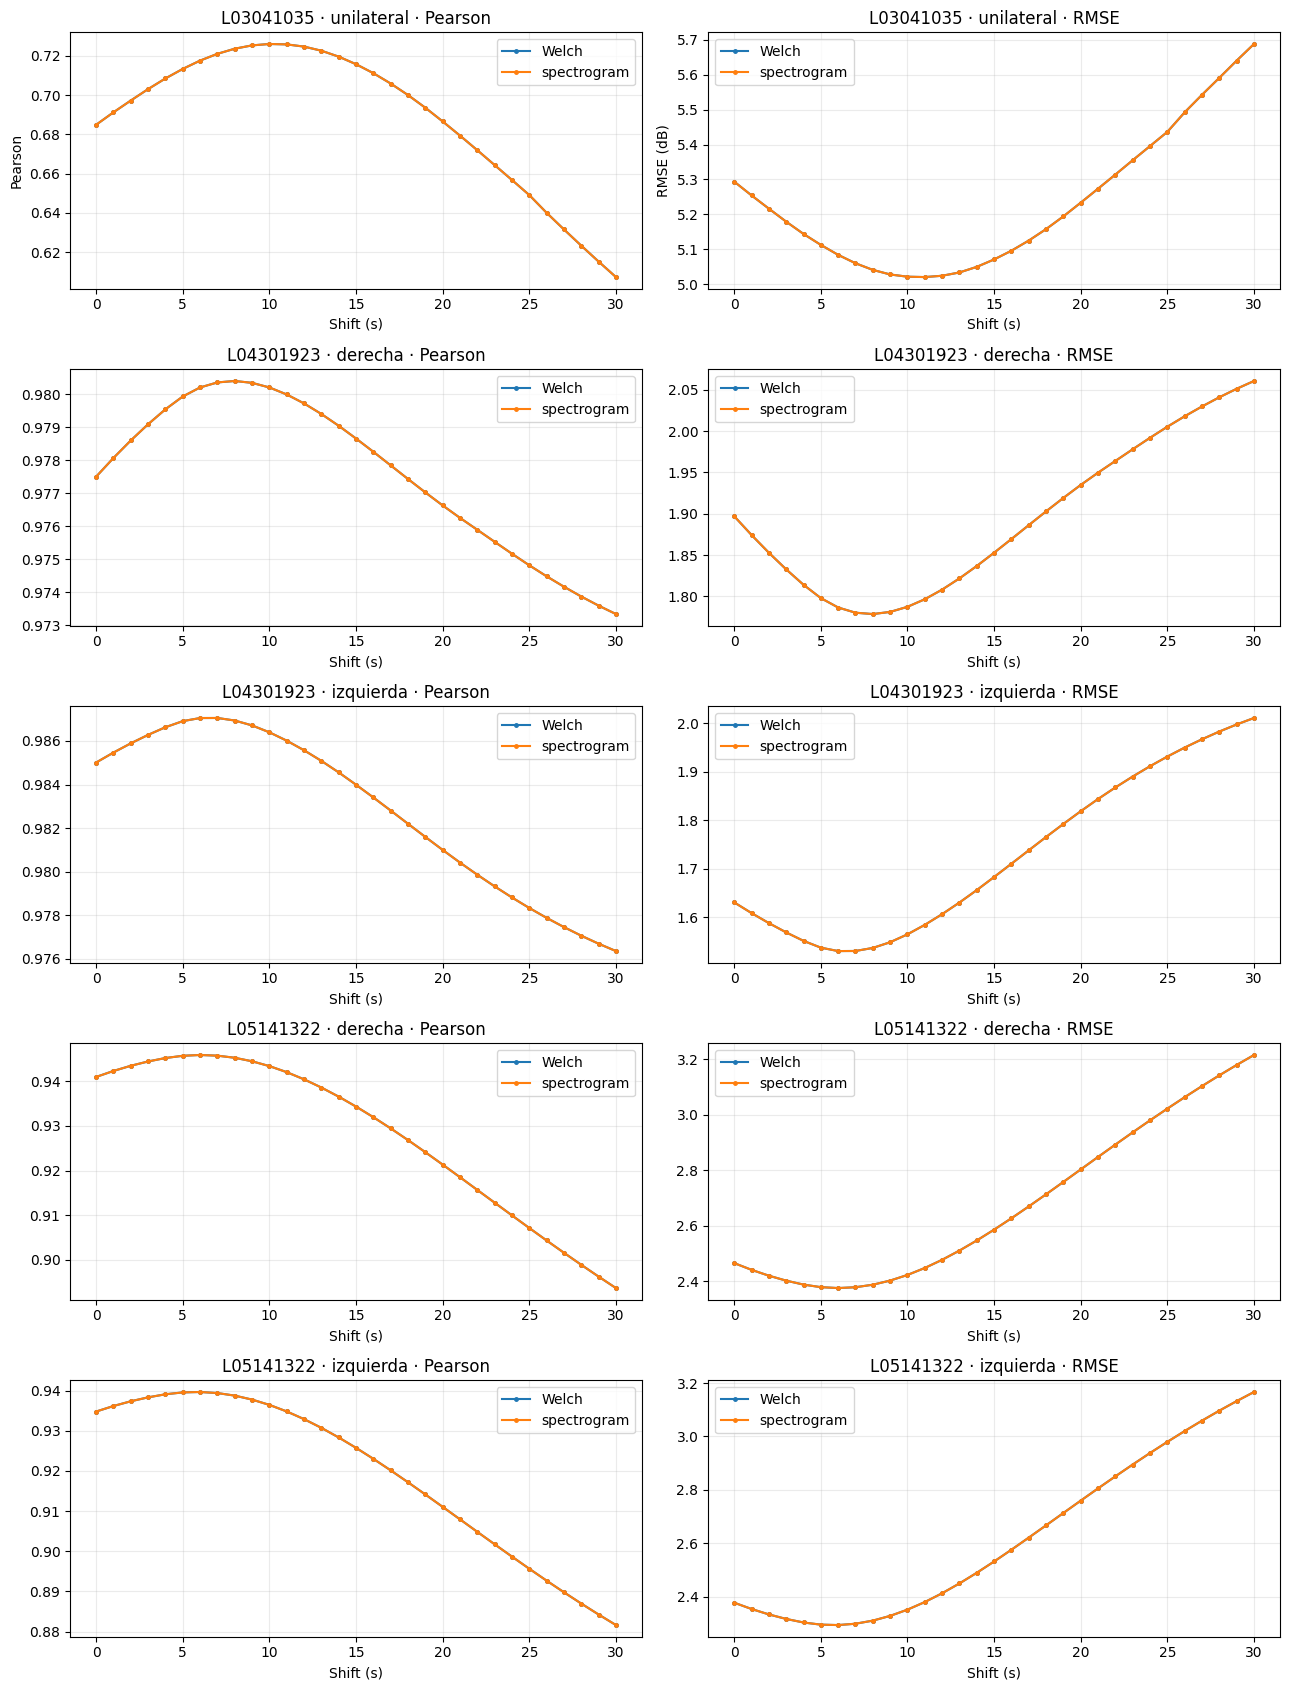

In [10]:
grupos = list(df_resultados.groupby(["registro", "lado"]))
fig, axes = plt.subplots(
    len(grupos),
    2,
    figsize=(13, 3.4 * len(grupos)),
    squeeze=False,
)

for fila, ((registro, lado), grupo) in enumerate(grupos):
    for metodo, datos in grupo.groupby("metodo"):
        axes[fila, 0].plot(
            datos["shift_s"],
            datos["Pearson"],
            marker="o",
            markersize=2.5,
            label=metodo,
        )
        axes[fila, 1].plot(
            datos["shift_s"],
            datos["RMSE"],
            marker="o",
            markersize=2.5,
            label=metodo,
        )

    axes[fila, 0].set_title(f"{registro} · {lado} · Pearson")
    axes[fila, 1].set_title(f"{registro} · {lado} · RMSE")
    for columna in range(2):
        axes[fila, columna].set_xlabel("Shift (s)")
        axes[fila, columna].grid(alpha=0.25)
        axes[fila, columna].legend()

axes[0, 0].set_ylabel("Pearson")
axes[0, 1].set_ylabel("RMSE (dB)")
plt.tight_layout()
plt.show()

## Exportación de resultados

In [11]:
SALIDA = Path.cwd()
df_resultados.to_csv(
    SALIDA / "resultados_welch_spectrogram.csv",
    index=False,
)
df_equivalencia.to_csv(
    SALIDA / "equivalencia_welch_spectrogram.csv",
    index=False,
)
mejores_pearson.to_csv(
    SALIDA / "mejores_shifts_welch_spectrogram.csv",
    index=False,
)

print("Archivos exportados:")
print(" - resultados_welch_spectrogram.csv")
print(" - equivalencia_welch_spectrogram.csv")
print(" - mejores_shifts_welch_spectrogram.csv")

Archivos exportados:
 - resultados_welch_spectrogram.csv
 - equivalencia_welch_spectrogram.csv
 - mejores_shifts_welch_spectrogram.csv


## Conclusión automática

In [12]:
max_psd = df_equivalencia["max_abs_diff_PSD"].max()
max_db = df_equivalencia["max_abs_diff_dB"].max()
max_metricas = diferencias_metricas[
    ["max_diff_Pearson", "max_diff_MAE", "max_diff_RMSE"]
].to_numpy().max()

print(f"Máxima diferencia PSD: {max_psd:.3e} µV²/Hz")
print(f"Máxima diferencia tras convertir a dB: {max_db:.3e} dB")
print(f"Máxima diferencia entre métricas: {max_metricas:.3e}")
print()

if max_psd <= 1e-12 and max_db <= 1e-12 and max_metricas <= 1e-12:
    print(
        "Conclusión: Welch y spectrogram son numéricamente equivalentes "
        "bajo esta configuración. Ninguno mejora Pearson, MAE o RMSE "
        "frente al .f_a, y ambos seleccionan los mismos shifts. La razón "
        "es que Welch recibe una única época de 2 s por llamada; por tanto, "
        "no promedia varios periodogramas y calcula el mismo periodograma "
        "modificado que cada columna temporal de spectrogram."
    )
else:
    print(
        "Conclusión: se han detectado diferencias numéricas. Deben revisarse "
        "las tablas anteriores para determinar si son relevantes y qué "
        "parámetro introduce la discrepancia."
    )

Máxima diferencia PSD: 0.000e+00 µV²/Hz
Máxima diferencia tras convertir a dB: 0.000e+00 dB
Máxima diferencia entre métricas: 0.000e+00

Conclusión: Welch y spectrogram son numéricamente equivalentes bajo esta configuración. Ninguno mejora Pearson, MAE o RMSE frente al .f_a, y ambos seleccionan los mismos shifts. La razón es que Welch recibe una única época de 2 s por llamada; por tanto, no promedia varios periodogramas y calcula el mismo periodograma modificado que cada columna temporal de spectrogram.


## Redacción propuesta para la memoria

> Se comparó la estimación espectral implementada mediante `welch` con la
> función `spectrogram`, manteniendo constantes el canal de EEG, el filtrado,
> la ventana Hann de 2 s, el avance de 1 s, la eliminación de la componente
> constante, el escalado como densidad espectral de potencia, la integración
> en intervalos de 0,5 Hz, la conversión a decibelios y el suavizado temporal.
> Bajo estas condiciones, ambas implementaciones produjeron resultados
> numéricamente equivalentes. Esto se debe a que la aplicación de Welch se
> realiza sobre épocas individuales cuya longitud coincide con `nperseg`, por
> lo que cada época contiene un único periodograma modificado y no existe un
> promedio adicional de subsegmentos. En consecuencia, sustituir Welch por
> `spectrogram` no modificó las métricas de Pearson, MAE o RMSE respecto a la
> matriz espectral exportada por el monitor.